c:\Users\soufi\Projects\credit-scoring-platform\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


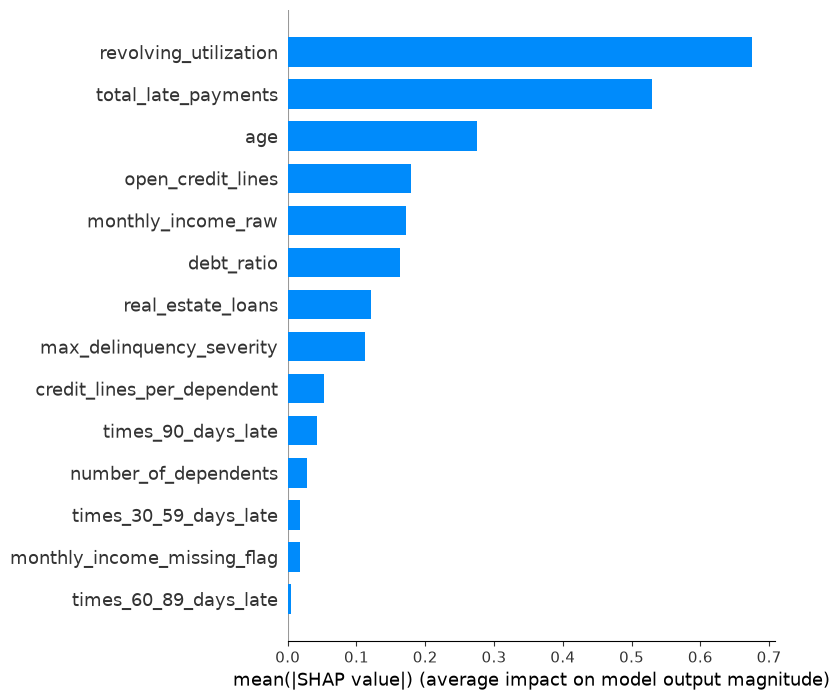

In [2]:
import joblib
import pandas as pd
import sys
sys.path.insert(0, "..")

from scoring_lib.preprocessing import clean_pipeline
from scoring_lib.features import build_features
from sklearn.model_selection import train_test_split

# Charger le modèle déjà entraîné et sauvegardé — pas besoin de ré-entraîner
model = joblib.load("../scoring_lib/model_lgbm.pkl")

# Recréer X_test (rapide, juste du preprocessing, pas d'entraînement)
df = pd.read_csv("cs-training.csv")
df_clean = clean_pipeline(df)
df_final = build_features(df_clean)

X = df_final.drop(columns=["customer_id", "target"])
y = df_final["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Maintenant on peut lancer SHAP directement
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

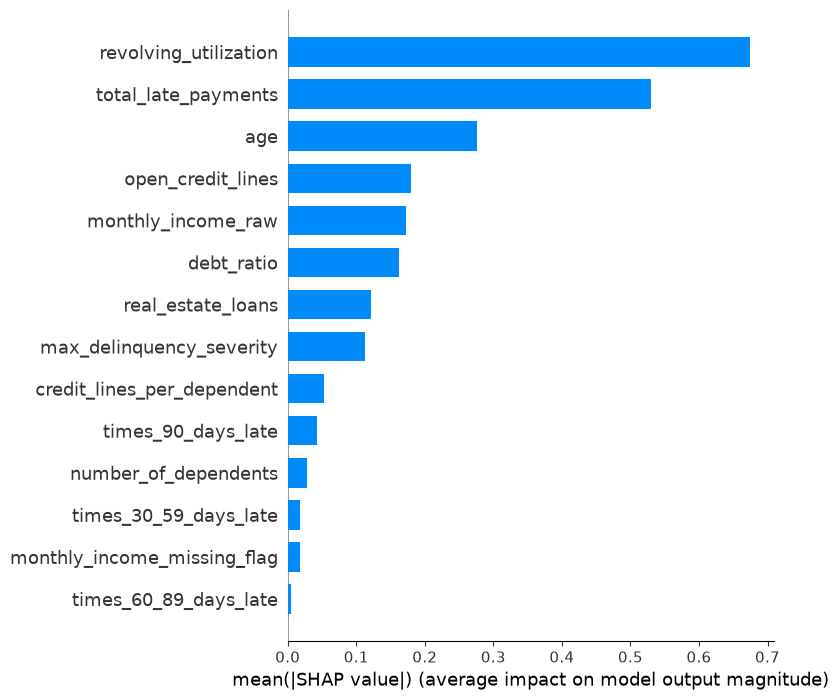

In [3]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../docs/shap_feature_importance.png", dpi=150)
plt.show()